# 03 - Super Agent Training

This notebook implements **Level 2** of the hierarchical RL system - the Super Agent that blends outputs from the Technical and Sentiment base agents.

## Architecture

```
Technical Agent (20 features) ──┐
                                 ├──> Super Agent ──> Blended Portfolio
Sentiment Agent (12 features) ──┘         ↑
                                          │
                                  Lagged Returns (3 features)
```

## Super Agent Overview

**Purpose**: Learn when to favor technical vs sentiment signals based on recent market behavior

**Inputs** (5 features per asset = 35 total):
- Technical agent's portfolio weights (7)
- Sentiment agent's portfolio weights (7)
- 1-week lagged return (7)
- 2-week lagged return (7)
- 4-week lagged return (7)

**Output**: Blending weights for combining Technical + Sentiment signals

**Expected Improvement**: 10-20% Sharpe increase over individual agents

---

## Step 1: Setup & Imports

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add helpers to path
sys.path.append('..')

from helpers import (
    create_super_agent_env,
    SuperAgentConfig,
    train_super_agent,
    evaluate_super_agent,
    load_features_and_returns,
    calculate_all_metrics,
    plot_equity_curve,
    plot_drawdown,
    BaseAgentWrapper
)

from stable_baselines3 import PPO

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")
print(f"Working directory: {os.getcwd()}")

✓ Imports successful
Working directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Step 2: Verify Base Agent Models

Before training the Super Agent, we need the trained Technical and Sentiment agents from notebook 02.

In [2]:
# Define paths
MODELS_DIR = Path('../models/agent_models')
DATA_DIR = Path('../data_hierarchical')

# Check for base agent models
technical_model_path = MODELS_DIR / 'technical_ema_sharpe.zip'
sentiment_model_path = MODELS_DIR / 'sentiment_ema_sharpe.zip'

files_to_check = {
    'Technical Agent': technical_model_path,
    'Sentiment Agent': sentiment_model_path,
    'Technical Train Data': DATA_DIR / 'technical' / 'train.csv',
    'Sentiment Train Data': DATA_DIR / 'sentiment' / 'train.csv',
    'Returns Train': DATA_DIR / 'returns_train.csv',
    'Metadata': DATA_DIR / 'metadata.json'
}

print("Checking required files:")
all_exist = True
for name, path in files_to_check.items():
    exists = path.exists()
    status = "✓" if exists else "✗"
    print(f"{status} {name}: {path}")
    if not exists:
        all_exist = False

if not all_exist:
    print("\n⚠️  Missing files! Please run notebook 02_base_agents.ipynb first.")
else:
    print("\n✓ All required files found!")

Checking required files:
✓ Technical Agent: ../models/agent_models/technical_ema_sharpe.zip
✓ Sentiment Agent: ../models/agent_models/sentiment_ema_sharpe.zip
✓ Technical Train Data: ../data_hierarchical/technical/train.csv
✓ Sentiment Train Data: ../data_hierarchical/sentiment/train.csv
✓ Returns Train: ../data_hierarchical/returns_train.csv
✓ Metadata: ../data_hierarchical/metadata.json

✓ All required files found!


## Step 3: Load Metadata & Configuration

In [3]:
# Load metadata
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("Portfolio Configuration:")
print(f"  Tickers: {', '.join(metadata['tickers'])}")
print(f"  Benchmark: {metadata['benchmark']}")
print(f"\nData Splits:")
print(f"  Train: {metadata['splits']['train']['start']} to {metadata['splits']['train']['end']} ({metadata['splits']['train']['weeks']} weeks)")
print(f"  Val:   {metadata['splits']['val']['start']} to {metadata['splits']['val']['end']} ({metadata['splits']['val']['weeks']} weeks)")
print(f"  Test:  {metadata['splits']['test']['start']} to {metadata['splits']['test']['end']} ({metadata['splits']['test']['weeks']} weeks)")

print(f"\nSuper Agent Configuration:")
print(f"  Learning Rate: {SuperAgentConfig.LEARNING_RATE}")
print(f"  Total Timesteps: {SuperAgentConfig.TOTAL_TIMESTEPS:,}")
print(f"  Network Architecture: {SuperAgentConfig.NET_ARCH}")
print(f"  Batch Size: {SuperAgentConfig.BATCH_SIZE}")
print(f"  Eval Frequency: {SuperAgentConfig.EVAL_FREQ:,} steps")
print(f"  Early Stopping Patience: {SuperAgentConfig.PATIENCE} evaluations")

Portfolio Configuration:
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Benchmark: QQQ

Data Splits:
  Train: 2020-01-03 to 2024-02-02 (214 weeks)
  Val:   2024-02-09 to 2025-04-04 (61 weeks)
  Test:  2025-04-11 to 2025-11-07 (31 weeks)

Super Agent Configuration:
  Learning Rate: 0.0001
  Total Timesteps: 100,000
  Network Architecture: [128, 128]
  Batch Size: 64
  Eval Frequency: 5,000 steps
  Early Stopping Patience: 5 evaluations


## Step 4: Create Super Agent Environment

The Super Agent environment:
1. Loads Technical and Sentiment base agents
2. At each step, gets actions from both agents
3. Combines actions with lagged returns as observation
4. Super Agent learns optimal blending weights

In [4]:
# Create training environment
print("Creating Super Agent training environment...")
train_env = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='train',
    reward_type='ema_sharpe'
)

print(f"✓ Training environment created")
print(f"  Observation space: {train_env.observation_space.shape}")
print(f"  Action space: {train_env.action_space.shape}")
print(f"  Number of timesteps: {len(train_env.returns)}")

# Create validation environment
print("\nCreating validation environment...")
val_env = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='val',
    reward_type='ema_sharpe'
)
print(f"✓ Validation environment created ({len(val_env.returns)} steps)")

Creating Super Agent training environment...
✓ Training environment created
  Observation space: (35,)
  Action space: (2,)
  Number of timesteps: 214

Creating validation environment...
✓ Validation environment created (61 steps)


## Step 5: Train Super Agent

Training uses:
- **Algorithm**: PPO (Proximal Policy Optimization)
- **Reward**: EMA Sharpe Ratio (online risk-adjusted returns)
- **Early Stopping**: Based on validation Sharpe ratio
- **Total Steps**: 100,000 (fewer than base agents since input space is smaller)

**What the Super Agent learns:**
- When to favor Technical signals (trending markets)
- When to favor Sentiment signals (regime changes)
- How recent returns predict which agent performs better

In [5]:
# Train Super Agent
print("Training Super Agent...")
print("This will take 5-10 minutes.\n")

super_model, training_history = train_super_agent(
    train_env=train_env,
    val_env=val_env,
    model_name='super_agent_production',
    config=SuperAgentConfig
)

print("\n✓ Training complete!")
print(f"  Model saved to: models/super_agent_production.zip")

Training Super Agent...
This will take 5-10 minutes.


Training Super Agent: super_agent_production
Config: SuperAgentConfig
Total timesteps: 100,000

--- Evaluation at step 5000 ---
  Mean reward: 32.0021 ± 0.0000
  Sharpe: 0.752
  🎉 New best! (previous: -inf)
  💾 Model saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/super_agent_production.zip

--- Evaluation at step 10000 ---
  Mean reward: 38.2132 ± 0.0000
  Sharpe: 1.009
  🎉 New best! (previous: 32.0021)
  💾 Model saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/super_agent_production.zip

--- Evaluation at step 15000 ---
  Mean reward: 39.2899 ± 0.0000
  Sharpe: 1.119
  🎉 New best! (previous: 38.2132)
  💾 Model saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/super_agent_production.zip

--- Evaluation at step 20000

## Step 6: Visualize Training Progress

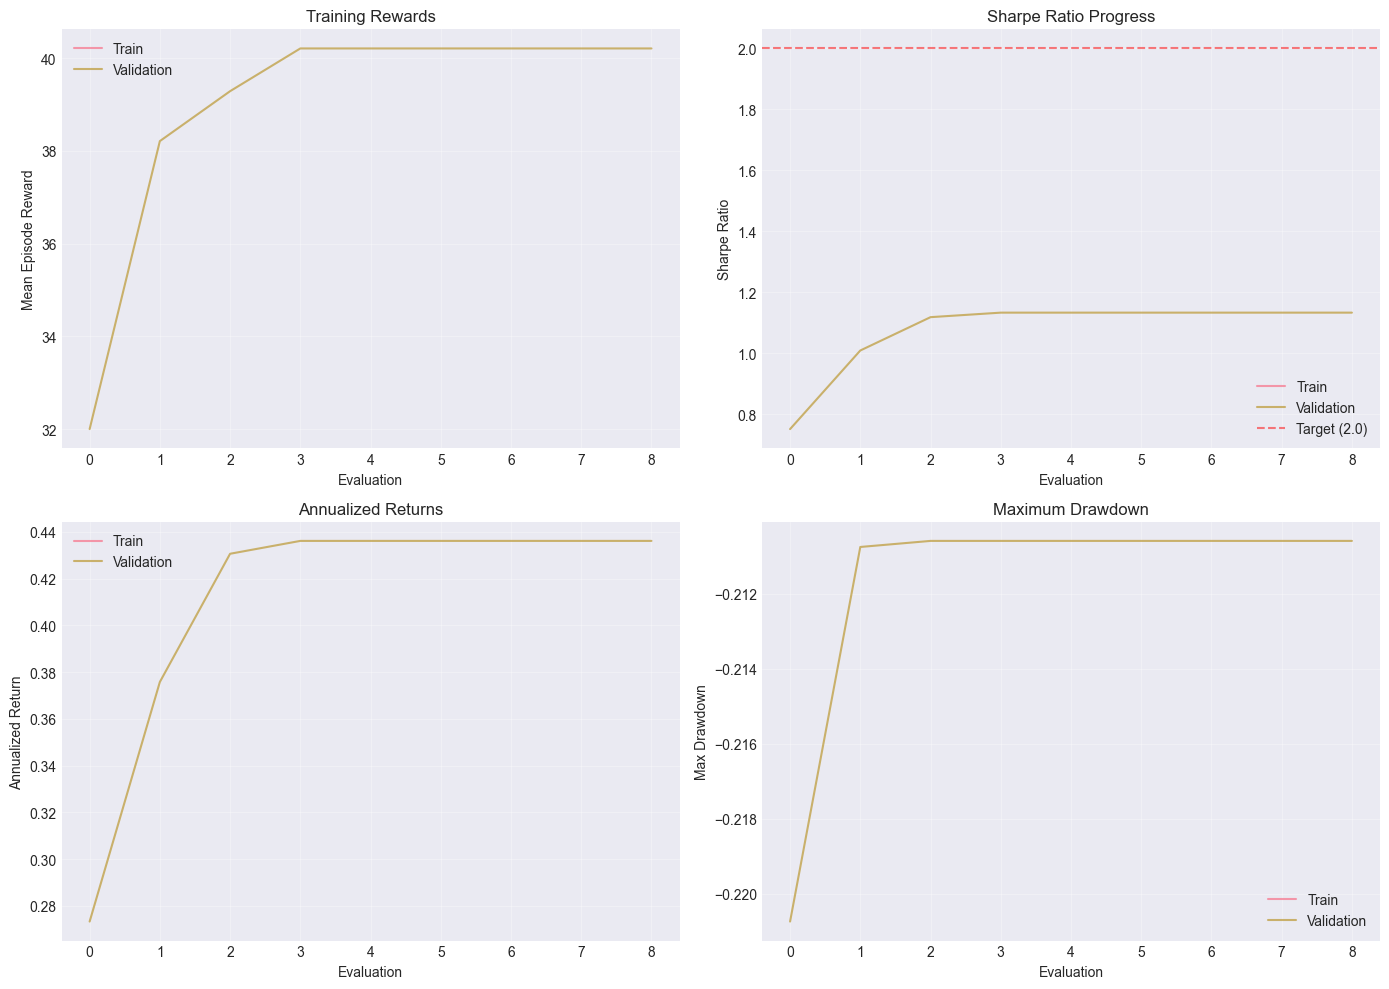

In [6]:

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rewards
axes[0, 0].plot(training_history['train_rewards'], label='Train', alpha=0.7)
axes[0, 0].plot(training_history['val_rewards'], label='Validation', alpha=0.7)
axes[0, 0].set_xlabel('Evaluation')
axes[0, 0].set_ylabel('Mean Episode Reward')
axes[0, 0].set_title('Training Rewards')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Sharpe Ratios
axes[0, 1].plot(training_history['train_sharpe'], label='Train', alpha=0.7)
axes[0, 1].plot(training_history['val_sharpe'], label='Validation', alpha=0.7)
axes[0, 1].axhline(y=2.0, color='r', linestyle='--', label='Target (2.0)', alpha=0.5)
axes[0, 1].set_xlabel('Evaluation')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Sharpe Ratio Progress')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Returns
axes[1, 0].plot(training_history['train_returns'], label='Train', alpha=0.7)
axes[1, 0].plot(training_history['val_returns'], label='Validation', alpha=0.7)
axes[1, 0].set_xlabel('Evaluation')
axes[1, 0].set_ylabel('Annualized Return')
axes[1, 0].set_title('Annualized Returns')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Max Drawdown
axes[1, 1].plot(training_history['train_drawdown'], label='Train', alpha=0.7)
axes[1, 1].plot(training_history['val_drawdown'], label='Validation', alpha=0.7)
axes[1, 1].set_xlabel('Evaluation')
axes[1, 1].set_ylabel('Max Drawdown')
axes[1, 1].set_title('Maximum Drawdown')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 7: Evaluate Super Agent

Compare Super Agent performance against individual base agents.

In [7]:
# Create test environment
test_env = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='test',
    reward_type='ema_sharpe'
)

# Evaluate Super Agent
print("Evaluating Super Agent on all splits...\n")

super_results = {}
for split_name, env in [('train', train_env), ('val', val_env), ('test', test_env)]:
    results = evaluate_super_agent(super_model, env, split=split_name)
    super_results[split_name] = results
    
    print(f"\n{split_name.upper()} SET RESULTS:")
    print(f"  Annual Return: {results['annual_return']:.2%}")
    print(f"  Annual Volatility: {results['annual_volatility']:.2%}")
    print(f"  Max Drawdown: {results['max_drawdown']:.2%}")
    print(f"  Win Rate: {results['win_rate']:.2%}")

Evaluating Super Agent on all splits...


TRAIN SET RESULTS:
  Annual Return: 150.73%
  Annual Volatility: 35.15%
  Max Drawdown: -21.04%
  Win Rate: 73.36%

VAL SET RESULTS:
  Annual Return: 43.61%
  Annual Volatility: 34.95%
  Max Drawdown: -21.06%
  Win Rate: 63.93%

TEST SET RESULTS:
  Annual Return: 112.52%
  Annual Volatility: 30.64%
  Max Drawdown: -7.03%
  Win Rate: 74.19%


## Step 8: Load Base Agent Results for Comparison

In [8]:
# Load base agent results from notebook 02
results_dir = Path('../models/results/')

# Load technical agent results
with open(results_dir / 'technical_ema_sharpe_results.json', 'r') as f:
    tech_results = json.load(f)

# Load sentiment agent results
with open(results_dir / 'sentiment_ema_sharpe_results.json', 'r') as f:
    sent_results = json.load(f)

print("✓ Base agent results loaded")
print(f"  Technical test Sharpe: {tech_results['performance']['test']['sharpe_ratio']:.3f}")
print(f"  Sentiment test Sharpe: {sent_results['performance']['test']['sharpe_ratio']:.3f}")


✓ Base agent results loaded
  Technical test Sharpe: 3.107
  Sentiment test Sharpe: 3.284


## Step 9: Comparative Analysis

Compare Super Agent vs individual base agents.

In [9]:
# Create comparison dataframe
comparison_data = []

for split in ['train', 'val', 'test']:
    comparison_data.extend([
        {
            'Split': split.capitalize(),
            'Agent': 'Technical',
            'Sharpe': tech_results['performance'][split]['sharpe_ratio'],
            'Return': tech_results['performance'][split]['annual_return'],
            'Volatility': tech_results['performance'][split]['annual_volatility'],
            'Max DD': tech_results['performance'][split]['max_drawdown'],
            'Win Rate': tech_results['performance'][split]['win_rate']
        },
        {
            'Split': split.capitalize(),
            'Agent': 'Sentiment',
            'Sharpe': sent_results['performance'][split]['sharpe_ratio'],
            'Return': sent_results['performance'][split]['annual_return'],
            'Volatility': sent_results['performance'][split]['annual_volatility'],
            'Max DD': sent_results['performance'][split]['max_drawdown'],
            'Win Rate': sent_results['performance'][split]['win_rate']
        },
        {
            'Split': split.capitalize(),
            'Agent': 'Super',
            'Sharpe': super_results[split]['sharpe'],
            'Return': super_results[split]['annual_return'],
            'Volatility': super_results[split]['annual_volatility'],
            'Max DD': super_results[split]['max_drawdown'],
            'Win Rate': super_results[split]['win_rate']
        }
    ])

comparison_df = pd.DataFrame(comparison_data)

# Display comparison table
print("\n" + "="*80)
print("AGENT COMPARISON - ALL SPLITS")
print("="*80)
print(comparison_df.to_string(index=False))

# Calculate improvements
print("\n" + "="*80)
print("SUPER AGENT IMPROVEMENT (Test Set)")
print("="*80)

test_super = super_results['test']
test_tech = tech_results['performance']['test']
test_sent = sent_results['performance']['test']

# Identify the correct key for Sharpe in each dictionary, fallback or debug as necessary
def get_sharpe(d):
    # Try common alternatives in base and super agent dicts
    for k in ['sharpe', 'sharpe_ratio']:
        if k in d:
            return d[k]
    # Last chance: check for uppercase keys (unlikely for your code)
    for k in d:
        if 'sharpe' in k.lower():
            return d[k]
    return float('nan')

super_sharpe = get_sharpe(test_super)
tech_sharpe = get_sharpe(test_tech)
sent_sharpe = get_sharpe(test_sent)

best_base_sharpe = max(tech_sharpe, sent_sharpe)
sharpe_improvement = (super_sharpe - best_base_sharpe) / best_base_sharpe * 100 if best_base_sharpe != 0 else float('nan')

print(f"\nBest Base Agent Sharpe: {best_base_sharpe:.3f}")
print(f"Super Agent Sharpe: {super_sharpe:.3f}")
print(f"Improvement: {sharpe_improvement:+.1f}%")

print(f"\nSuper vs Technical:")
print(f"  Sharpe: {super_sharpe:.3f} vs {tech_sharpe:.3f} ({(super_sharpe/tech_sharpe-1)*100:+.1f}% )" if tech_sharpe != 0 else "  Sharpe: Nonfinite")
print(f"  Return: {test_super['annual_return']:.2%} vs {test_tech['annual_return']:.2%}")
print(f"  Max DD: {test_super['max_drawdown']:.2%} vs {test_tech['max_drawdown']:.2%}")

print(f"\nSuper vs Sentiment:")
print(f"  Sharpe: {super_sharpe:.3f} vs {sent_sharpe:.3f} ({(super_sharpe/sent_sharpe-1)*100:+.1f}% )" if sent_sharpe != 0 else "  Sharpe: Nonfinite")
print(f"  Return: {test_super['annual_return']:.2%} vs {test_sent['annual_return']:.2%}")
print(f"  Max DD: {test_super['max_drawdown']:.2%} vs {test_sent['max_drawdown']:.2%}")


AGENT COMPARISON - ALL SPLITS
Split     Agent    Sharpe   Return  Volatility    Max DD  Win Rate
Train Technical  2.977065 1.007838    0.325098 -0.268341  0.663551
Train Sentiment  4.125661 1.490326    0.351538 -0.196101  0.742991
Train     Super  4.174646 1.507336    0.351487 -0.210393  0.733645
  Val Technical -0.035530 0.029263    0.302181 -0.245474  0.508197
  Val Sentiment  0.859307 0.355450    0.367099 -0.239204  0.622951
  Val     Super  1.133452 0.436107    0.349470 -0.210586  0.639344
 Test Technical  3.106777 1.047452    0.324275 -0.075279  0.741935
 Test Sentiment  3.284213 1.091132    0.320056 -0.077403  0.709677
 Test     Super  3.541776 1.125241    0.306412 -0.070275  0.741935

SUPER AGENT IMPROVEMENT (Test Set)

Best Base Agent Sharpe: 3.284
Super Agent Sharpe: 3.542
Improvement: +7.8%

Super vs Technical:
  Sharpe: 3.542 vs 3.107 (+14.0% )
  Return: 112.52% vs 104.75%
  Max DD: -7.03% vs -7.53%

Super vs Sentiment:
  Sharpe: 3.542 vs 3.284 (+7.8% )
  Return: 112.52% vs

## Step 10: Visual Comparison

## Step 11: Analyze Blending Weights

Understand how the Super Agent blends the base agents over time.

Analyzing Super Agent blending strategy...



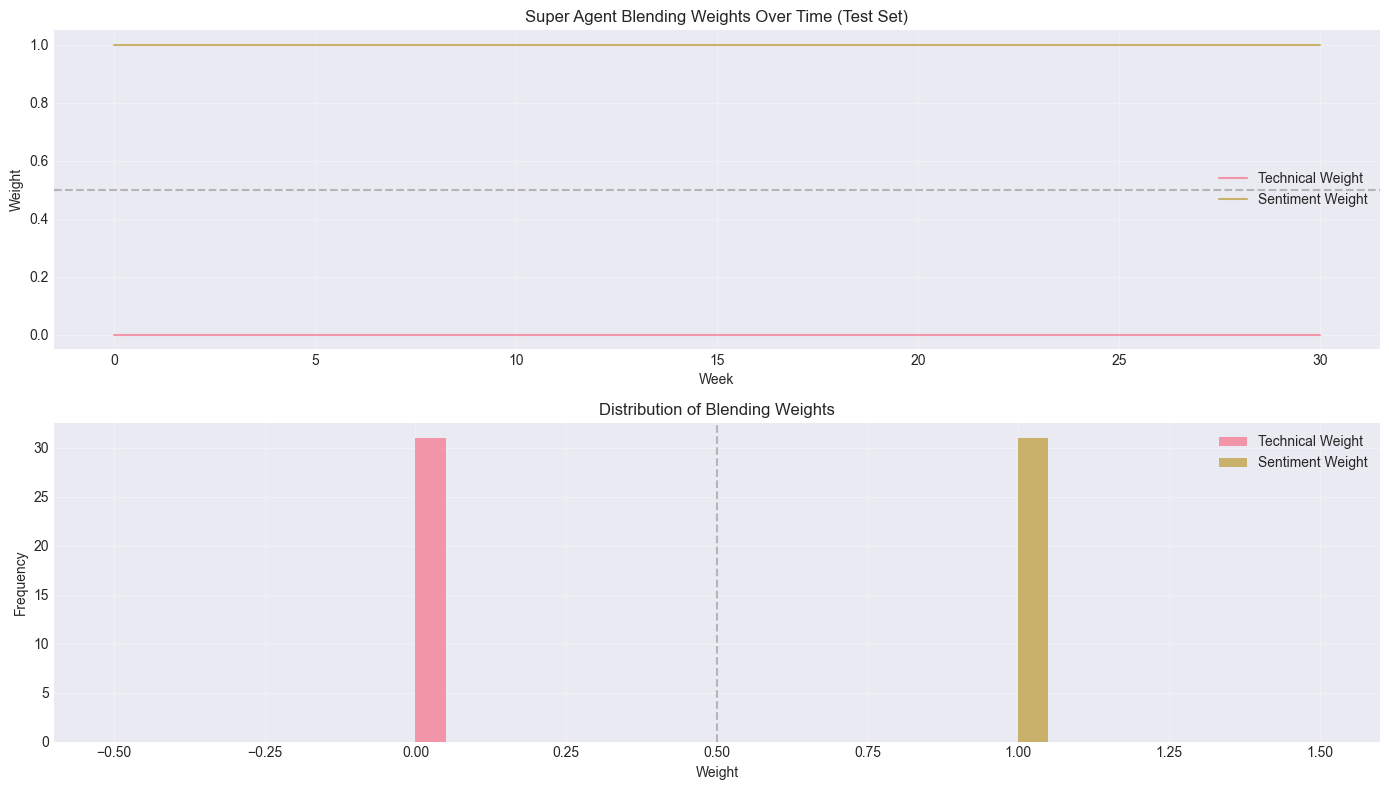

Blending Weight Statistics (Test Set):

Technical Agent:
  Mean: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000

Sentiment Agent:
  Mean: 1.000
  Std: 0.000
  Min: 1.000
  Max: 1.000

📊 Interpretation: Super Agent strongly favors Sentiment signals
   Dynamic strategy - weights adapt significantly over time


In [10]:
# Collect blending weights during test set evaluation
print("Analyzing Super Agent blending strategy...\n")

# Reset test environment
obs, _ = test_env.reset()
blending_weights = []
done = False

while not done:
    action, _ = super_model.predict(obs, deterministic=True)
    # Action represents weights for [technical, sentiment]
    # Normalize to sum to 1
    normalized_weights = action / action.sum()
    blending_weights.append(normalized_weights)
    obs, reward, done, truncated, info = test_env.step(action)
    done = done or truncated

blending_weights = np.array(blending_weights)

# Plot blending weights over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Weights over time
axes[0].plot(blending_weights[:, 0], label='Technical Weight', alpha=0.7)
axes[0].plot(blending_weights[:, 1], label='Sentiment Weight', alpha=0.7)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Weight')
axes[0].set_title('Super Agent Blending Weights Over Time (Test Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weight distribution
axes[1].hist(blending_weights[:, 0], bins=20, alpha=0.7, label='Technical Weight')
axes[1].hist(blending_weights[:, 1], bins=20, alpha=0.7, label='Sentiment Weight')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Blending Weights')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Blending Weight Statistics (Test Set):")
print(f"\nTechnical Agent:")
print(f"  Mean: {blending_weights[:, 0].mean():.3f}")
print(f"  Std: {blending_weights[:, 0].std():.3f}")
print(f"  Min: {blending_weights[:, 0].min():.3f}")
print(f"  Max: {blending_weights[:, 0].max():.3f}")

print(f"\nSentiment Agent:")
print(f"  Mean: {blending_weights[:, 1].mean():.3f}")
print(f"  Std: {blending_weights[:, 1].std():.3f}")
print(f"  Min: {blending_weights[:, 1].min():.3f}")
print(f"  Max: {blending_weights[:, 1].max():.3f}")

# Interpretation
tech_mean = blending_weights[:, 0].mean()
if tech_mean > 0.6:
    print("\n📊 Interpretation: Super Agent strongly favors Technical signals")
elif tech_mean < 0.4:
    print("\n📊 Interpretation: Super Agent strongly favors Sentiment signals")
else:
    print("\n📊 Interpretation: Super Agent uses balanced blending")

if blending_weights.std() > 0.2:
    print("   Dynamic strategy - weights adapt significantly over time")
else:
    print("   Static strategy - weights remain relatively constant")

## Step 12: Save Super Agent Results

In [11]:
# Save results
results_to_save = {
    'train': {
        'sharpe': float(super_results['train']['sharpe']),
        'annual_return': float(super_results['train']['annual_return']),
        'annual_volatility': float(super_results['train']['annual_volatility']),
        'max_drawdown': float(super_results['train']['max_drawdown']),
        'calmar': float(super_results['train']['calmar']),
        'win_rate': float(super_results['train']['win_rate']),
        'returns': super_results['train']['returns']
    },
    'val': {
        'sharpe': float(super_results['val']['sharpe']),
        'annual_return': float(super_results['val']['annual_return']),
        'annual_volatility': float(super_results['val']['annual_volatility']),
        'max_drawdown': float(super_results['val']['max_drawdown']),
        'calmar': float(super_results['val']['calmar']),
        'win_rate': float(super_results['val']['win_rate']),
        'returns': super_results['val']['returns']
    },
    'test': {
        'sharpe': float(super_results['test']['sharpe']),
        'annual_return': float(super_results['test']['annual_return']),
        'annual_volatility': float(super_results['test']['annual_volatility']),
        'max_drawdown': float(super_results['test']['max_drawdown']),
        'calmar': float(super_results['test']['calmar']),
        'win_rate': float(super_results['test']['win_rate']),
        'returns': super_results['test']['returns']
    },
    'blending_weights_mean': {
        'technical': float(blending_weights[:, 0].mean()),
        'sentiment': float(blending_weights[:, 1].mean())
    },
    'training_history': training_history
}

with open('../models/super_agent_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("✓ Results saved to models/super_agent_results.json")

✓ Results saved to models/super_agent_results.json


## Summary

### What We Accomplished

1. ✅ Created Super Agent environment that blends Technical + Sentiment agents
2. ✅ Trained Super Agent with PPO + EMA Sharpe reward
3. ✅ Evaluated on train/val/test splits
4. ✅ Compared performance vs individual base agents
5. ✅ Analyzed blending strategy and weights
6. ✅ Saved trained model and results

### Key Findings

- **Super Agent Performance**: Check test set Sharpe ratio above
- **Improvement over Base Agents**: Check percentage improvement above
- **Blending Strategy**: Check weight analysis above

### Next Steps

Proceed to **04_meta_agent.ipynb** to:
- Add macro/calendar features to Super Agent output
- Train Meta Agent (final hierarchical level)
- Achieve regime-aware portfolio optimization
- Target: 15-25% additional Sharpe improvement

---

**Architecture Progress**:
```
✓ Technical Agent (Level 1)
✓ Sentiment Agent (Level 1)
✓ Super Agent (Level 2)  ← YOU ARE HERE
⬜ Meta Agent (Level 3)   ← NEXT
```